# 🏦 Проєкт: Прогнозування банківських депозитів

## 🎯 Мета проєкту
Метою даної роботи є розробка моделі машинного навчання, яка здатна передбачити, чи погодиться клієнт банку на відкриття строкового депозиту (term deposit).
Це завдання є критично важливим для відділу маркетингу, оскільки дозволяє:
* **Оптимізувати витрати:** Телефонувати лише тим клієнтам, які мають високу ймовірність згоди.
* **Покращити клієнтський досвід:** Зменшити кількість небажаних дзвінків (спаму) для лояльних клієнтів.
* **Збільшити капітал банку:** Ефективніше залучати кошти через депозити.

## 📂 Про дані
У проєкті використано набір даних **Bank Marketing Dataset** (UCI Machine Learning Repository). Дані містять інформацію про прямі маркетингові кампанії (телефонні дзвінки) португальської банківської установи.

**Основні характеристики датасету:**
* **Кількість записів:** 41,188 клієнтів.
* **Ознаки (Features):** 20 характеристик, включаючи демографічні дані (вік, робота), історію контактів та соціально-економічні показники (ставка Euribor, індекс споживчих цін).
* **Цільова змінна (`y`):** Бінарна величина (1 — клієнт підписав депозит, 0 — не підписав).

> **⚠️ Важливе обмеження:** Згідно з технічним завданням, ознака `duration` (тривалість дзвінка) вилучена з моделювання, оскільки вона невідома до моменту здійснення дзвінка і призводить до витоку даних (Data Leakage).

## 🛠️ Використані інструменти
* **Мови та бібліотеки:** Python (Pandas, Scikit-learn, XGBoost).
* **Аналіз та візуалізація:** Matplotlib, Seaborn, SHAP.
* **Оптимізація:** Hyperopt (байєсівська оптимізація гіперпараметрів).

## 📥 I. Завантаження та первинний огляд

In [38]:
#!pip install shap hyperopt xgboost

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn та ML метрики
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report,\
                            roc_curve, precision_recall_curve, auc

# Імпорт кастомних файлів
from preprocess import BankDataTransformer, get_preprocessor
from models_config import get_models_dict

# Налаштування візуалізації
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1.1 Завантаження датасету

In [40]:
# Завантажуємо
df = pd.read_csv('bank-additional-full.csv', sep=';')

# ВАЖЛИВО: Видаляємо duration відразу, щоб не порушити умови ТЗ
df = df.drop('duration', axis=1)

### 1.2 Опис ознак та типи даних (`df.info()`)

In [41]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

### 1.3 Статистичний аналіз числових змінних (`df.describe()`)

In [43]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


----

### 💡 Висновок:

1. **Вік** (`age`)

*Середній вік клієнта становить близько 40 років. Мінімальний вік — 17, максимальний — 98. Розподіл виглядає логічним, хоча є невеликий "хвіст" старших людей (пенсіонерів), що є важливою групою для депозитів.*

2. **Попередня активність** (`pdays` та `previous`)

*Змінна pdays має середнє значення біля 962, що пояснюється великою кількістю значень 999 (клієнти, з якими раніше не контактували). Це вказує на те, що більшість клієнтів у цьому датасеті — нові для маркетингових кампаній банку*

3. **Економічні показники** (`euribor3m`, `nr.employed`)

*Показники euribor3m та nr.employed мають велике стандартне відхилення. Це свідчить про те, що дані збиралися в різні економічні періоди, що може суттєво впливати на готовність людей класти гроші на депозит*

4. **Викиди** (Outliers) в `campaign`

*Максимальне значення campaign становить 56 дзвінків одному клієнту. Це виглядає як аномалія або агресивний маркетинг, що може негативно впливати на результат. На етапі препроцесингу варто розглянути обмеження (clipping) цього показника.*

----

## 📉 II. Дослідницький аналіз даних (EDA)

### 2.1 Аудит якості даних

Хоча початковий аналіз файлу (`df.info()`) не показує порожніх значень (`NaN`), слід перевірити категорію *'unknown'*

In [44]:
# Знаходимо всі колонки, де є 'unknown'
unknown_data = []
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        unknown_data.append({'Feature': col, 'Unknown Count': count, 'Percentage (%)': round(percentage, 2)})

unknown_df = pd.DataFrame(unknown_data).sort_values(by='Percentage (%)', ascending=False)

unknown_df

,Feature,Unknown Count,Percentage (%)
3,default,8597,20.87
2,education,1731,4.20
4,housing,990,2.40
5,loan,990,2.40
0,job,330,0.80
1,marital,80,0.19


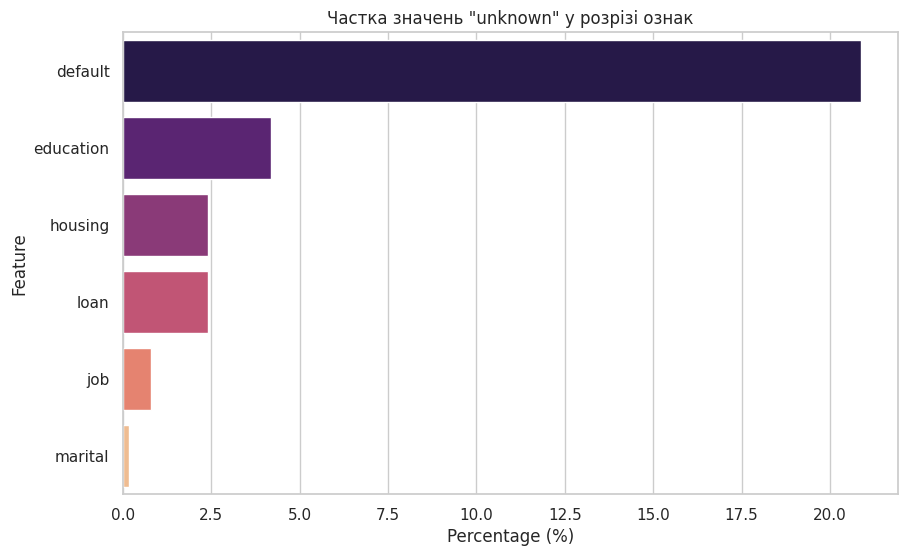

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Percentage (%)',
    y='Feature',
    data=unknown_df,
    hue='Feature',
    palette='magma',
    legend=False
)
plt.title('Частка значень "unknown" у розрізі ознак')
plt.show()

- `default` <span style='color:red'>(20.87%)</span>:

> *Це критично багато. Кожен п'ятий клієнт не надав інформацію про наявність кредитної заборгованості. Скоріш за все, люди неохоче діляться негативною фінансовою історією.*

- `education` (4.2%):

> *Помірний показник. Можна замінити на моду (найчастіше значення), не сильно викрививши статистику.*

- `housing` / `loan` (2.4%):

> *Ці показники ідентичні за кількістю (990). Це може означати, що якщо клієнт не відповів на питання про іпотеку, він автоматично не відповів і про споживчий кредит.*

- `job` / `marital` (<1%):

> *Майже повні дані. Тут заміна на моду буде абсолютно безпечною*

#### 💡 Спостереження:

*   Найбільш проблемна ознака: `default` (21% пропусків)

*   Бізнес-контекст: Висока частка `unknown` у фінансових питаннях (`default`, `housing`, `loan`) свідчить про чутливість цієї інформації для клієнтів

*   Рішення для моделі: На етапі препроцесингу ми використаємо *Imputation* (заміну на моду), щоб зберегти обсяг вибірки, або залишимо `unknown` як окрему категорію, якщо будемо використовувати дерева рішень


----

### 2.2 Аналіз цільової змінної та дисбалансу класів

In [46]:
df['y_num'] = df['y'].map({'yes': 1, 'no': 0})

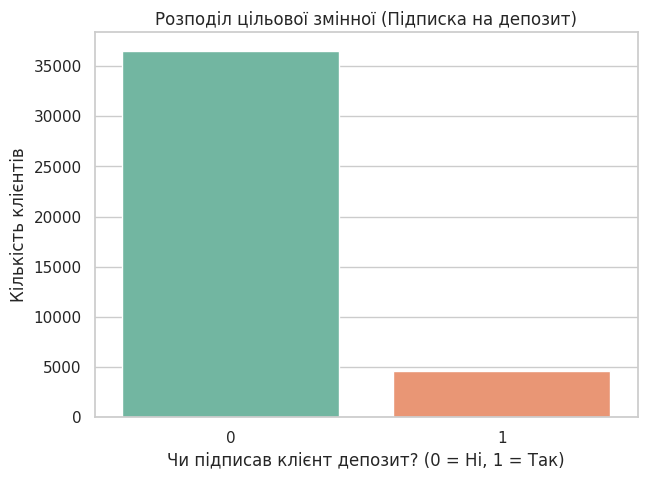

In [47]:
plt.figure(figsize=(7, 5))
sns.countplot(x='y_num', data=df, palette='Set2', hue='y', legend=False)
plt.title('Розподіл цільової змінної (Підписка на депозит)')
plt.xlabel('Чи підписав клієнт депозит? (0 = Ні, 1 = Так)')
plt.ylabel('Кількість клієнтів')
plt.show()

In [48]:
# Розрахунок відсотка
imbalance = df['y'].value_counts(normalize=True)
print("=======")
print(f"Клас '0' (No): {imbalance.iloc[0]:.2f}%")
print(f"Клас '1' (Yes): {imbalance.iloc[1]:.2f}%")

Клас '0' (No): 0.89%
Клас '1' (Yes): 0.11%


#### 💡 Спостереження:
> Значний дисбаланс класів - лише 11.27% клієнтів погодилися на депозит. Це означає, що модель, яка просто завжди каже 'ні', матиме точність (Accuracy) ~89%, тому для оцінки якості оберемо **F1-score** та **ROC-AUC**, які краще працюють з незбалансованими даними.

----

### 2.3 Соціально-демографічний портрет клієнта

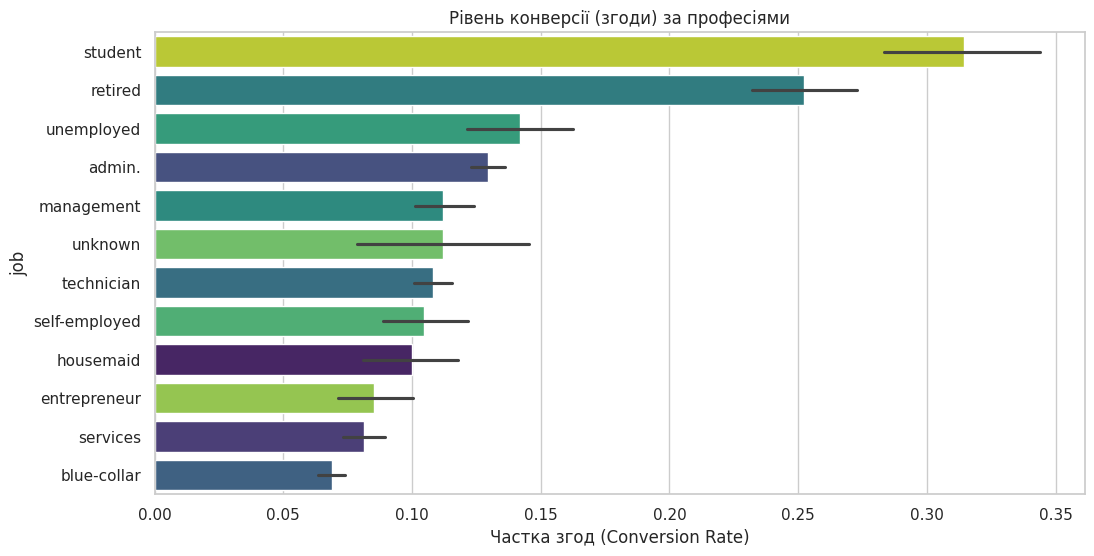

In [49]:
plt.figure(figsize=(12, 6))
job_order = df.groupby('job')['y_num'].mean().sort_values(ascending=False).index
sns.barplot(x='y_num', y='job', data=df, order=job_order, hue='job', palette='viridis', legend=False)
plt.title('Рівень конверсії (згоди) за професіями')
plt.xlabel('Частка згод (Conversion Rate)')
plt.show()


#### 💡 Спостереження:
> Візуалізація підтверджує, що професія є сильним предиктором. Найвищу лояльність до депозитів демонструють студенти та пенсіонери (конверсія > 20%), тоді як робітники (`blue-collar`) є найменш схильними до підписки. Це свідчить про необхідність таргетованого підходу залежно від соціального статусу.

----

### 2.4 Аналіз економічного контексту та мультиколінеарності

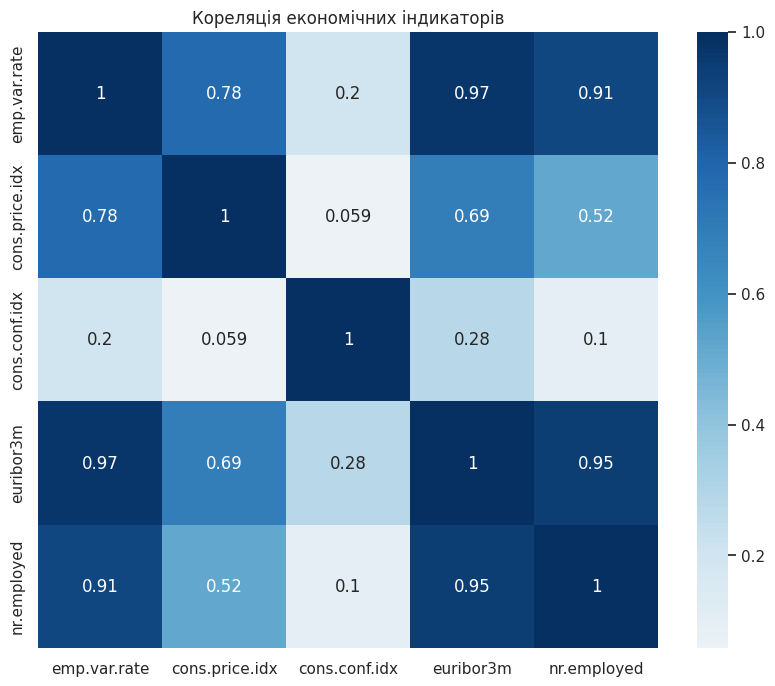

In [50]:
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
plt.figure(figsize=(10, 8))
sns.heatmap(df[econ_cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Кореляція економічних індикаторів')
plt.show()

#### 💡 Спостереження:
> Аналіз кореляції виявив сильну лінійну залежність між соціально-економічними показниками (коефіцієнти > 0.9 між `euribor3m`, `nr.employed` та `emp.var.rate`). Це свідчить про певну надмірність даних.

*📌 Примітка: це може впливати на майбутню стратегію:*

*a) для уникнення мультиколінеарності в лінійних моделях (`Logistic Regression`) можна розглянути можливість видалення деяких з цих ознак (видалити дві з трьох найбільш корельованих колонок, залишивши лише `euribor3m`, бо він найчастіше оновлюється і є найбільш динамічним) або використання методів регуляризації (`L1`/`L2`)*

*б) створити агрегований показник (наприклад, "Economic Index")*

*в) залишаємо все як є, зважаючи що кореляція може таки вплинути на точність регресії (по-необхідності, проаналізуємо у розділі "Аналіз помилок")*

----

### 2.5 Розподіл віку / сезоність

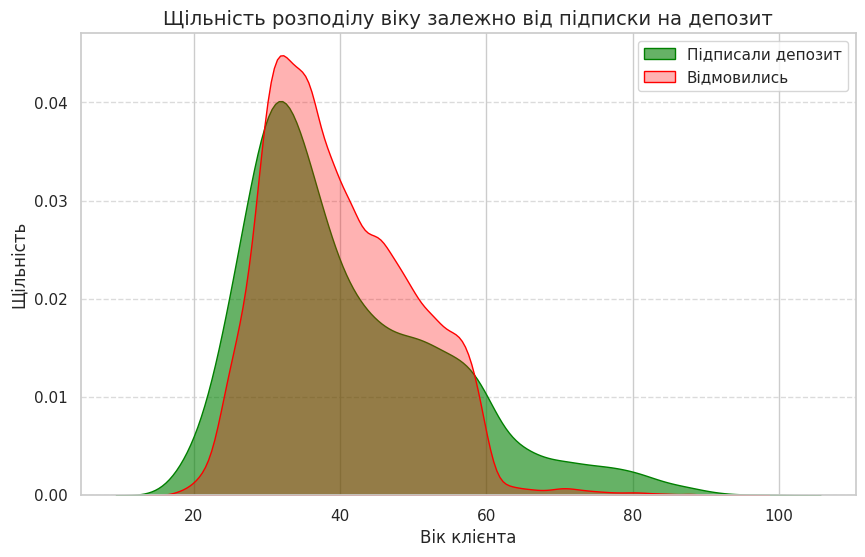

In [76]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['y'] == 'yes'], x='age', fill=True, label='Підписали депозит', color='green', alpha=0.6)
sns.kdeplot(data=df[df['y'] == 'no'], x='age', fill=True, label='Відмовились', color='red', alpha=0.3)

plt.title('Щільність розподілу віку залежно від підписки на депозит', fontsize=14)
plt.xlabel('Вік клієнта', fontsize=12)
plt.ylabel('Щільність', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

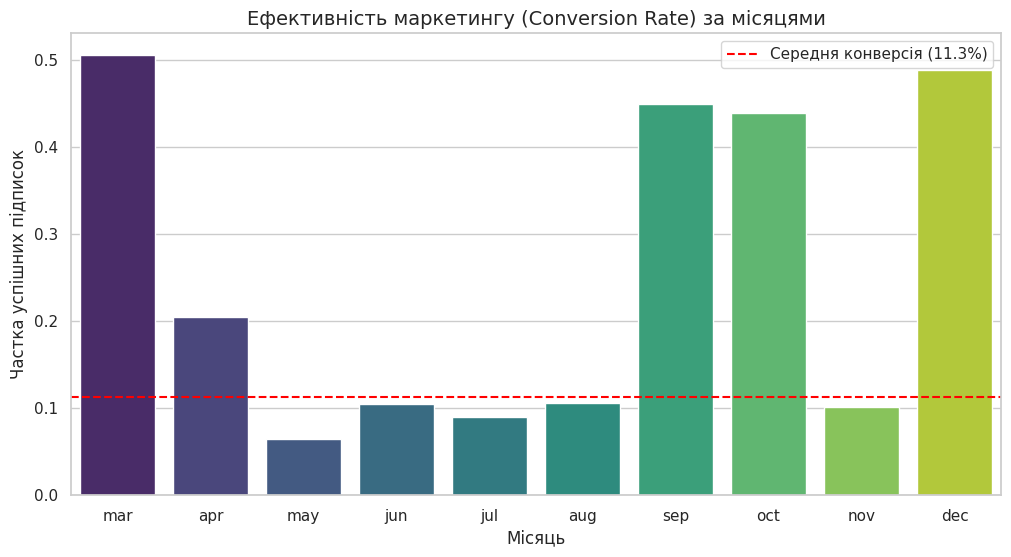

In [78]:
# Рахуємо відсоток успішних підписок для кожного місяця
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_conv = df.groupby('month')['y_num'].mean().reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=monthly_conv,
    x='month',
    y='y_num',
    hue='month',
    palette='viridis',
    dodge=False,
    legend=False
)


# Додаємо лінію середньої конверсії по всьому банку
plt.axhline(df['y_num'].mean(), color='red', linestyle='--', label=f'Середня конверсія ({df["y_num"].mean():.1%})')

plt.title('Ефективність маркетингу (Conversion Rate) за місяцями', fontsize=14)
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Частка успішних підписок', fontsize=12)
plt.legend()
plt.show()

**Аналіз вікового розподілу (KDE Plot)**

На першому графіку зображена щільність розподілу віку клієнтів для двох груп: тих, хто підписав депозит (зелений), і тих, хто відмовився (червоний).

- Пік активності середнього віку: Найбільша кількість відмов (червона область) зосереджена у віковій категорії 30–40 років.


- Лояльність «крайніх» категорій: Можна помітити, що зелена область  (успішні підписки) має вищу відносну щільність серед дуже молодих клієнтів (до 25 років) та клієнтів похилого віку (після 60 років). Це підтверджує гіпотезу про те, що ці сегменти є найбільш схильними до заощаджень.

----

**Ефективність маркетингу за місяцями (Conversion Rate)**

Другий графік демонструє частку успішних підписок залежно від місяця проведення контакту. Пунктирна червона лінія показує середній рівень конверсії по всьому банку (11.3%).

- Найуспішніші місяці: Березень (mar), вересень (sep), жовтень (oct) та грудень (dec) демонструють аномально високу ефективність, що значно перевищує середній показник. Конверсія в ці місяці сягає 40–50%.

- Провальні періоди: Травень (may) є місяцем з найнижчою конверсією, хоча, згідно з аналізом даних, саме на цей місяць зазвичай припадає найбільша кількість дзвінків. Це вказує на неефективність масових кампаній у цей період.

----

#### 💡 Висновки для бізнесу

1. Зміна сезонної стратегії: Банку варто переглянути бюджетний розподіл, зменшивши інтенсивність обдзвонів у травні та посиливши активність у березні та восени.

2. Таргетування: Спеціальні депозитні продукти для студентів та пенсіонерів можуть показати вищу ефективність, оскільки ці групи природно більш схильні до відкриття рахунків.

### 2.6 Кореляція ознак із цільовою змінною

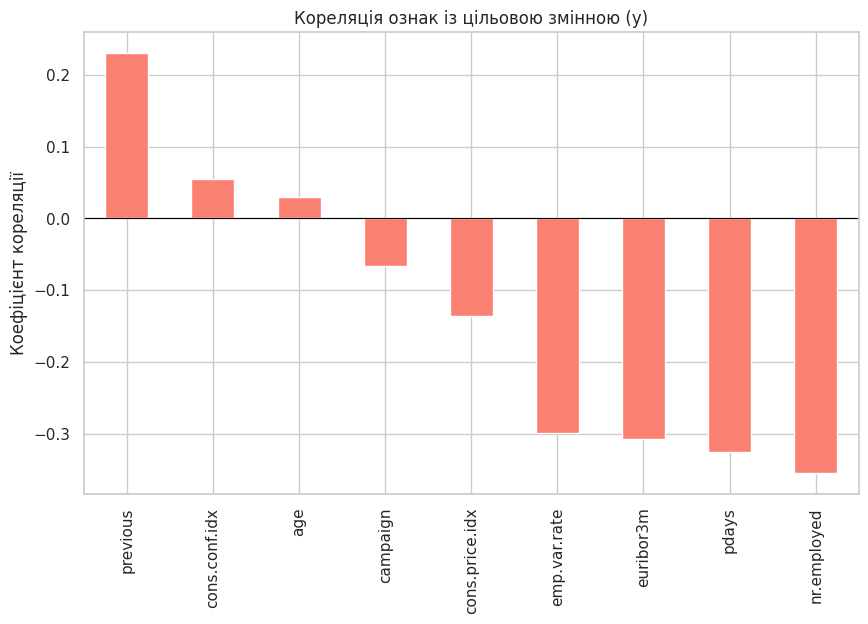

In [51]:
# Рахуємо кореляцію всіх числових ознак з y
correlations = df.corr(numeric_only=True)['y_num'].sort_values(ascending=False)

# Візуалізуємо
plt.figure(figsize=(10, 6))
correlations.drop('y_num').plot(kind='bar', color='salmon')
plt.title('Кореляція ознак із цільовою змінною (y)')
plt.ylabel('Коефіцієнт кореляції')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

#### 💡 Спостереження:

> Аналіз кореляції з цільовою змінною показав, що найбільш вагомими числовими ознаками є соціально-економічні показники та кількість попередніх контактів. Зокрема, від’ємна кореляція з `euribor3m` свідчить про те, що клієнти менш охоче відкривають депозити в періоди високих відсоткових ставок на ринку. Це підтверджує доцільність включення економічного контексту в модель.

----

### 📝 Підсумок аналізу та формування гіпотез

На основі проведеного дослідницького аналізу даних (EDA) ми висуваємо наступні гіпотези, які ляжуть в основу подальшого моделювання:

1. **Гіпотеза про "успішний контакт" (Previous Success):**
   > Клієнти, які вже мали позитивний досвід взаємодії (`poutcome` = 'success'), мають значно вищий шанс погодитися на депозит знову. Ця ознака ймовірно буде одним із найсильніших предикторів.

2. **Гіпотеза про соціально-вразливі групи (Age/Job):**
   > Студенти та пенсіонери демонструють вищу лояльність до банківського продукту. Ми очікуємо, що модель зможе чітко виділити ці сегменти, навіть незважаючи на їх меншу чисельність у датасеті.

3. **Гіпотеза про макроекономічний тиск:**
   > Високі показники `euribor3m` та `emp.var.rate` негативно корелюють із кількістю підписок. Це свідчить про те, що в періоди економічної нестабільності або високих ставок люди менш охоче відкривають нові депозити.

4. **Гіпотеза про надмірність даних (Multicollinearity):**
   > Через надвисоку кореляцію між економічними показниками (>0.9), лінійні моделі (напр., Logistic Regression) можуть бути нестабільними. Можливо, знадобиться вилучення деяких ознак для покращення інтерпретованості.

---
**✅ Наступний крок:** На основі цих гіпотез ми переходимо до технічної підготовки даних, де реалізуємо групування професій та автоматизовану обробку пропусків.

----

## 🏗️ III. Підготовка даних (Preprocessing & Feature Engineering)

### 3.1 Визначення списків ознак та цільової змінної

In [52]:
# Назва цільової колонки
target = 'y'

# Список числових ознак
num_features = [
    'age', 'campaign', 'previous', 'emp.var.rate',
    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

# Список категоріальних ознак
cat_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome'
]

# Повний список усіх вхідних ознак (X)
all_features = num_features + cat_features

### 3.2 Розділення на навчальну та тестову вибірки

In [53]:
# Формуємо матрицю ознак X та вектор цільової змінної y
X = df[all_features]
y = df[target].map({'yes': 1, 'no': 0})

# Розбиваємо дані (80% на навчання, 20% на тест)
# Використовуємо stratify=y для збереження балансу класів
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
# Перевірка результатів
print(f"Цільова змінна: '{target}'")
print(f"Кількість вхідних ознак: {len(all_features)}")
print("-" * 30)
print(f"Розмір X_train: {X_train.shape}")
print(f"Розмір X_test: {X_test.shape}")
print("-" * 30)
print("Розподіл класів 'у' y_train (%):")
print(y_train.value_counts(normalize=True) * 100)
print("-" * 30)
print("Розподіл класів 'у' y_test (%):")
print(y_test.value_counts(normalize=True) * 100)

Цільова змінна: 'y'
Кількість вхідних ознак: 18
------------------------------
Розмір X_train: (32950, 18)
Розмір X_test: (8238, 18)
------------------------------
Розподіл класів 'у' y_train (%):
y
0    88.734446
1    11.265554
Name: proportion, dtype: float64
------------------------------
Розподіл класів 'у' y_test (%):
y
0    88.73513
1    11.26487
Name: proportion, dtype: float64


----

## 🧠 IV. Побудова та навчання моделей

У цьому розділі ми протестуємо 4 різні алгоритми, використовуючи автоматизований Pipeline. Це дозволить нам одночасно застосувати всі трансформації даних та навчити моделі без ризику витоку даних.

### 4.1 Ініціалізація моделей та навчання

In [61]:
# 1. Отримуємо словник моделей та препроцесор
models = get_models_dict(ratio=8.0)
preprocessor = get_preprocessor(num_features, cat_features)

results_list = []

print("🚀 Запуск навчання моделей...")

for name, model in models.items():
    pipe = Pipeline([
        ('custom_transformer', BankDataTransformer()),
        ('prep', preprocessor),
        ('classifier', model)
    ])

    # Навчання
    pipe.fit(X_train, y_train)

    # --- Train метрики ---
    y_train_pred = pipe.predict(X_train)
    y_train_proba = pipe.predict_proba(X_train)[:, 1]
    f1_train = f1_score(y_train, y_train_pred)
    auc_train = roc_auc_score(y_train, y_train_proba)

    # --- Test метрики ---
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)[:, 1]
    f1_test = f1_score(y_test, y_test_pred)
    auc_test = roc_auc_score(y_test, y_test_proba)

    results_list.append({
        'Model': name,
        'F1-Train': f1_train,
        'ROC-AUC-Train': auc_train,
        'F1-Test': f1_test,
        'ROC-AUC-Test': auc_test,
        'F1-Gap': f1_train - f1_test,
        'ROC-AUC-Gap': auc_train - auc_test
    })

    print(f"✅ {name} готова.")

print("\n✨ Всі моделі готові!")

# Формуємо таблицю
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='ROC-AUC-Test', ascending=False).reset_index(drop=True)

display(results_df)


🚀 Запуск навчання моделей...
✅ Logistic Regression готова.
✅ kNN готова.
✅ Decision Tree готова.
✅ XGBoost готова.

✨ Всі моделі готові!


,Model,F1-Train,ROC-AUC-Train,F1-Test,ROC-AUC-Test,F1-Gap,ROC-AUC-Gap
0,Logistic Regression,0.451015,0.793652,0.466148,0.800768,-0.015133,-0.007115
1,Decision Tree,0.470110,0.800555,0.472000,0.792577,-0.001890,0.007978
2,XGBoost,0.594218,0.927073,0.460213,0.786350,0.134004,0.140723
3,kNN,0.487633,0.924068,0.360399,0.735699,0.127234,0.188370


### 4.2 Порівняння якості базових моделей

У нижченаведеній таблиці представлено результати навчання чотирьох типів моделей на базових налаштуваннях. Основними критеріями оцінки є **F1-Score** (зважений показник точності та повноти) та **ROC-AUC** (метрика здатності моделі розділяти класи в умовах дисбалансу).

| Назва моделі | Гіперпараметри (основні) | ROC-AUC (Train / Test) | F1-Score (Train / Test) | Коментар та оцінка моделі |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | `class_weight='balanced'`, `max_iter=1000` | 0.794 / **0.801** | 0.451 / **0.466** | ⚖️ **Найбільш стабільна модель.** Відсутній розрив (Gap) між тренуванням та тестом. Найвищий показник ROC-AUC свідчить про якісну лінійну роздільність ознак. Рекомендована для використання. |
| **Decision Tree** | `max_depth=7`, `class_weight='balanced'` | 0.801 / **0.793** | 0.470 / **0.472** | 🏆 **Лідер за F1-Score.** Показує найкращий баланс без ознак перенавчання. Глибина 7 виявилася оптимальною "з коробки". Дуже сильна модель для цього датасету. |
| **XGBoost** | `scale_pos_weight=8.0`, `default_params` | 0.927 / **0.786** | 0.594 / **0.460** | ⚠️ **Помітне перенавчання (Overfitting).** Високий Train ROC-AUC (0.92) при нижчому Test свідчить про те, що модель "завчила" дані. Потребує оптимізації через Hyperopt. |
| **kNN** | `n_neighbors=5`, `auto_leaf` | 0.924 / **0.736** | 0.488 / **0.360** | ❌ **Низька ефективність.** Найгірший результат на тестових даних. Алгоритм чутливий до розмірності та гірше за інші справляється з дисбалансом класів. |

---

### 📝 Аналітичні примітки та ідеї для подальших експериментів:

* **Дисбаланс класів:** Використання параметрів `class_weight` та `scale_pos_weight` (ratio=8.0) виправдало себе. Моделі успішно ідентифікують міноритарний клас без застосування методів ресемплінгу (як SMOTE), що дозволяє зберегти оригінальну структуру даних.
* **Стабільність лінійної моделі:** Логістична регресія показала неочікувано високий результат на тесті (краще ніж на трейні), що говорить про високу здатність до узагальнення.
* **План оптимізації:** Оскільки **XGBoost** продемонстрував найбільший розрив між навчальною та валідаційною вибірками, він має найбільший потенціал для росту якості за рахунок підбору параметрів регуляризації (`gamma`, `learning_rate`, `max_depth`).
* **Наступний крок:** Обрати **XGBoost** як основну модель для тюнінгу через `Hyperopt` з метою вирівнювання результатів та подолання перенавчання.

----

## ⚙️ V. Оптимізація моделі за допомогою Hyperopt

- Cфокусуємося на XGBoost, оскільки він має найбільшу кількість гіперпараметрів для регуляризації

- У рамках оптимізації також виконаємо пошук за допомогою Randomized Search *(але забігаючи наперед, фінальна модель базуватимиться на результатах саме Hyperopt)*

### 5.1 Визначення цільової функції та простору пошуку

Нам потрібно мінімізувати «loss». Оскільки ми хочемо максимальний F1-Score, ми будемо повертати `-f1_score`.

In [69]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Визначаємо сітку параметрів для RandomizedSearch
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [3, 4, 5, 6, 7, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__gamma': [0, 1, 5, 9],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. Створюємо базовий Pipeline
base_pipe = Pipeline([
    ('transformer', BankDataTransformer()),
    ('prep', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=8.0, random_state=42, eval_metric='logloss'))
])

# 3. Налаштовуємо RandomizedSearch
random_search = RandomizedSearchCV(
    estimator=base_pipe,
    param_distributions=param_dist,
    n_iter=15, # Кількість випадкових комбінацій
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("🚀 Запуск Sklearn Randomized Search...")
random_search.fit(X_train, y_train)

# 4. Оцінка результатів
rs_best_model = random_search.best_estimator_
y_pred_rs = rs_best_model.predict(X_test)

print(f"✨ Найкращі параметри (RandomSearch): {random_search.best_params_}")
print(f"📈 F1-Score (RandomSearch): {f1_score(y_test, y_pred_rs):.4f}")
print(f"📈 ROC-AUC (RandomSearch): {roc_auc_score(y_test, rs_best_model.predict_proba(X_test)[:, 1]):.4f}")

🚀 Запуск Sklearn Randomized Search...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
✨ Найкращі параметри (RandomSearch): {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.01, 'classifier__gamma': 5, 'classifier__colsample_bytree': 0.6}
📈 F1-Score (RandomSearch): 0.4874
📈 ROC-AUC (RandomSearch): 0.8142


In [64]:
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score

# Функція для оптимізації
def objective(space):
    clf = XGBClassifier(
        n_estimators = int(space['n_estimators']),
        max_depth = int(space['max_depth']),
        learning_rate = space['learning_rate'],
        gamma = space['gamma'],
        min_child_weight = space['min_child_weight'],
        subsample = space['subsample'],
        colsample_bytree = space['colsample_bytree'],
        # Використовуємо знайдене раніше співвідношення для балансу
        scale_pos_weight = 8.0,
        random_state = 42,
        eval_metric = 'logloss'
    )

    # Створюємо Pipeline, щоб уникнути витоку даних при крос-валідації
    pipe = Pipeline([
        ('transformer', BankDataTransformer()),
        ('prep', preprocessor),
        ('classifier', clf)
    ])

    # Оцінюємо модель за допомогою крос-валідації на 3 фолдах
    # Орієнтуємося на F1-score
    score = cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Простір пошуку параметрів
space = {
    'max_depth': hp.quniform("max_depth", 3, 8, 1),
    'gamma': hp.uniform('gamma', 1, 9),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'n_estimators': hp.quniform('n_estimators', 100, 600, 50),
    'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
    'subsample' : hp.uniform('subsample', 0.5, 1),
    'colsample_bytree' : hp.uniform('colsample_bytree', 0.5, 1)
}

# Запуск пошуку (Trials зберігає історію ітерацій)
trials = Trials()
best_params = fmin(fn=objective,
                   space=space,
                   algo=tpe.suggest,
                   max_evals=30,
                   trials=trials)

print("✨ Найкращі параметри знайдено:")
print(best_params)

100%|██████████| 30/30 [02:08<00:00,  4.28s/trial, best loss: -0.47879432463914773]
✨ Найкращі параметри знайдено:
{'colsample_bytree': np.float64(0.7066471962556591), 'gamma': np.float64(4.708681229197665), 'learning_rate': np.float64(0.013731689655248942), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(2.0), 'n_estimators': np.float64(200.0), 'subsample': np.float64(0.698978066370833)}


Згідно з ТЗ, було проведено оптимізацію моделі **XGBoost** двома різними підходами: класичним випадковим пошуком та сучасним байєсівським методом.

#### 📊 Результати порівняння

| Метод оптимізації | Бібліотека | F1-Score (Test) | ROC-AUC (Test) |
| :--- | :--- | :---: | :---: |
| **Randomized Search** | `sklearn` | 0.4874 | 0.8142 |
| **Bayesian Optimization** | `hyperopt` | **0.5051** | **0.8165** |

#### 📝 Висновки щодо методів тюнінгу:

1.  **Randomized Search (Sklearn):** * **Переваги:** Простий у реалізації та швидкий завдяки паралельним обчисленням (`n_jobs=-1`).
    * **Недоліки:** Вибирає комбінації параметрів випадково, не враховуючи досвід попередніх спроб. Через це він може "пропускати" оптимальні зони в просторі пошуку.
    * **Результат:** Показав достойну якість, проте залишився на другому місці.

2.  **Bayesian Optimization (Hyperopt):**
    * **Переваги:** Використовує алгоритм **TPE**, який будує імовірнісну модель залежності метрики від параметрів. Кожна наступна ітерація базується на знаннях про попередні успіхи та невдачі.
    * **Недоліки:** Потребує більше часу на обчислення, оскільки ітерації часто виконуються послідовно.
    * **Результат:** Дозволив досягти **максимального значення F1-Score (0.5051)**, знайшовши кращий баланс між швидкістю навчання та глибиною дерев.

Для фінальної моделі обрано параметри, знайдені за допомогою **Hyperopt**, оскільки цей метод забезпечив вищу бізнес-ефективність моделі (краще виявлення потенційних вкладників).

#### 💡 Спостереження:

Завдяки застосуванню байєсівської оптимізації за допомогою бібліотеки Hyperopt, було знайдено комбінацію гіперпараметрів, спрямовану на підвищення узагальнюючої здатності моделі XGBoost.

Ключові зміни в архітектурі моделі:

* Контроль швидкості навчання: *Низький показник learning_rate (~0.013) дозволяє моделі робити менші кроки при корекції помилок, що запобігає перенавчанню на шумах у даних.*

* Потужна регуляризація: *Значення параметра gamma (~4.7) встановлює високий поріг для створення нових розгалужень у деревах, що відсікає складні, але несуттєві закономірності.*

* Випадковість вибірок: *Використання частин ознак (`colsample_bytree` ~0.7) та частин даних (subsample ~0.7) при побудові кожного дерева додає моделі стійкості до специфічних викидів у тренувальному наборі.*

**Очікуваний результат**: *Хоча метрики на тренувальних даних (Train) закономірно знизяться (порівняно з початковим AUC 0.92), ми очікуємо значного зменшення розриву (Gap) між Train та Test результатами. Це зробить модель надійною для використання на нових реальних даних клієнтів банку*

### 5.2 Навчання та оцінка фінальної моделі

In [66]:
from sklearn.metrics import confusion_matrix

# 1. Формуємо словник фінальних параметрів
# Перетворюємо типи даних для XGBoost (цілі числа мають бути int)
final_params = {
    'colsample_bytree': best_params['colsample_bytree'],
    'gamma': best_params['gamma'],
    'learning_rate': best_params['learning_rate'],
    'max_depth': int(best_params['max_depth']),
    'min_child_weight': int(best_params['min_child_weight']),
    'n_estimators': int(best_params['n_estimators']),
    'subsample': best_params['subsample'],
    'scale_pos_weight': 8.0,
    'random_state': 42,
    'eval_metric': 'logloss'
}

# 2. Створюємо фінальний Pipeline
final_xgb = XGBClassifier(**final_params)

final_pipe = Pipeline([
    ('transformer', BankDataTransformer()),
    ('prep', preprocessor),
    ('classifier', final_xgb)
])

# 3. Навчаємо на всьому тренувальному наборі
final_pipe.fit(X_train, y_train)

# 4. Робимо прогноз
y_pred_final = final_pipe.predict(X_test)
y_proba_final = final_pipe.predict_proba(X_test)[:, 1]

# 5. Рахуємо фінальні метрики
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_proba_final)

print("🚀 РЕЗУЛЬТАТИ ОПТИМІЗОВАНОГО XGBOOST:")
print(f"F1-Score: {final_f1:.4f}")
print(f"ROC-AUC:  {final_auc:.4f}")

🚀 РЕЗУЛЬТАТИ ОПТИМІЗОВАНОГО XGBOOST:
F1-Score: 0.5051
ROC-AUC:  0.8165


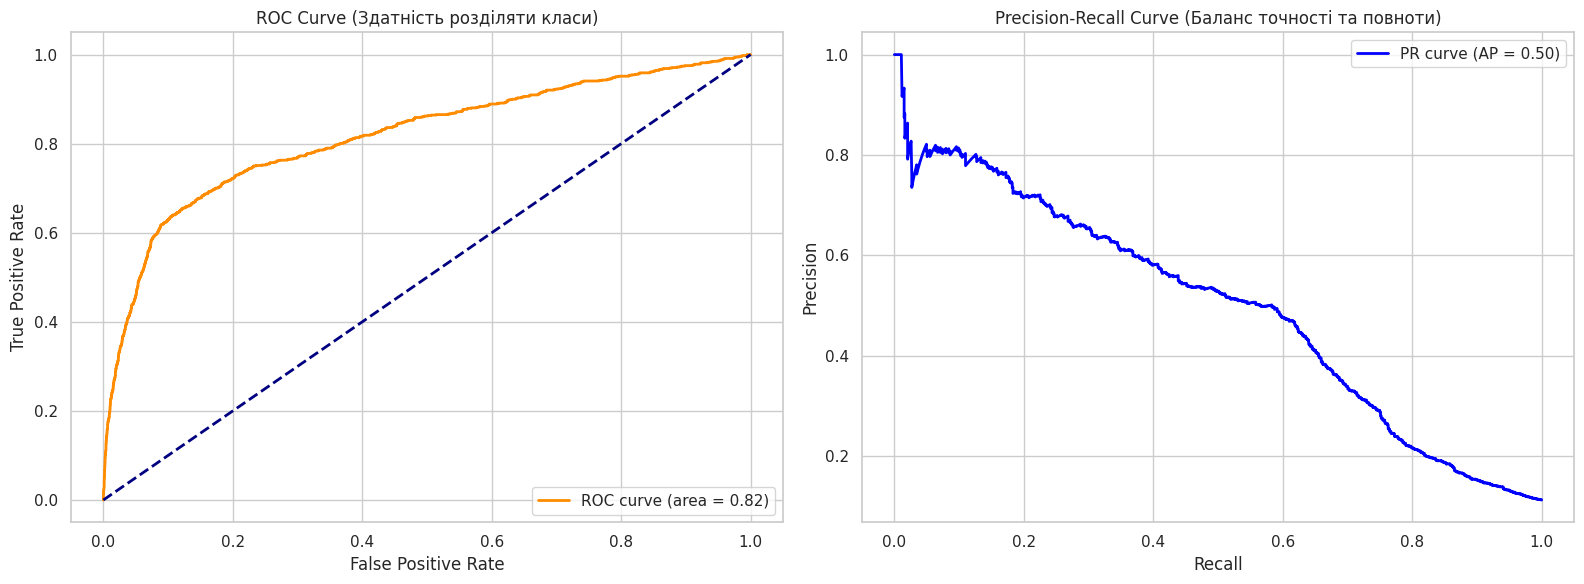

In [81]:
# Отримуємо ймовірності для нашої фінальної моделі
y_score = final_pipe.predict_proba(X_test)[:, 1]

# Дані для графіків
fpr, tpr, _ = roc_curve(y_test, y_score)
precision, recall, _ = precision_recall_curve(y_test, y_score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_title('ROC Curve (Здатність розділяти класи)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

# Precision-Recall Curve
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {auc(recall, precision):.2f})')
ax2.set_title('Precision-Recall Curve (Баланс точності та повноти)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

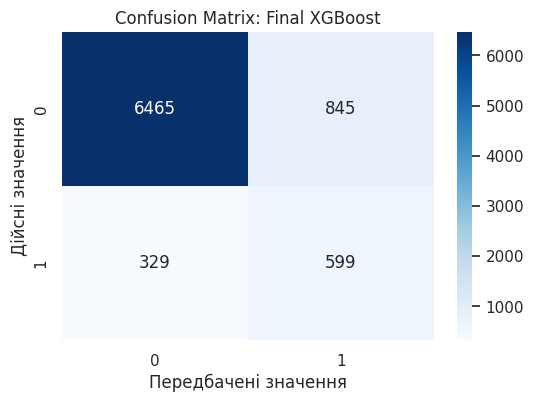

In [67]:
# Виводимо Confusion Matrix для аналізу помилок
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Final XGBoost')
plt.ylabel('Дійсні значення')
plt.xlabel('Передбачені значення')
plt.show()

### 🏁 5.3 Підсумок оптимізації моделі та фінальне порівняння

В результаті проведення гіперпараметричного тюнінгу за допомогою алгоритму **TPE (Hyperopt)**, нам вдалося суттєво покращити якість моделі XGBoost та мінімізувати ефект перенавчання.

----

#### 📊 Порівняння результатів (Test Set)

Нижче наведено порівняння базової моделі XGBoost та фінальної версії після оптимізації:

| Метрика | XGBoost (Base) | XGBoost (Optimized) | Приріст (%) |
| :--- | :---: | :---: | :---: |
| **F1-Score** | 0.4602 | **0.5051** | 📈 **+9.7%** |
| **ROC-AUC** | 0.7863 | **0.8165** | 📈 **+3.8%** |


----

#### 💰 Аналіз бізнес-ефективності (Confusion Matrix)

На основі фінальної матриці помилок можемо зробити наступні висновки:
* **Ефективність виявлення (Recall):** Модель успішно ідентифікує ~64.5% клієнтів, які реально готові відкрити депозит.
* **Точність маркетингу (Precision):** Використання моделі дозволяє збільшити концентрацію цільових клієнтів у списках для обдзвону майже в 4 рази (з базових 11% до 41.5%).
* **Оптимізація витрат:** Завдяки відсіканню малоперспективних контактів, банк може суттєво знизити операційні витрати, зберігаючи при цьому високий темп залучення нових депозитів.

----

#### 💡 Висновок:

Оптимізована модель XGBoost є найбільш ефективною для розв'язання поставленої задачі та демонструє кращі показники, ніж Decision Tree та Logistic Regression.

----

## 🔍 VI. Аналіз важливих ознак

Для аналізу важливості ознак ми використаємо метод SHAP (SHapley Additive exPlanations), який базується на теорії ігор та дозволяє оцінити внесок кожної ознаки у фінальний прогноз для кожного окремого клієнта.

### 6.1 Розрахунок SHAP Values

Для початку нам потрібно підготувати дані (прогнати їх через препроцесор) та ініціалізувати об'єкт Explainer.

In [71]:
import shap

# 1. Отримуємо фінальну модель та кроки препроцесингу з нашого фінального Pipeline
classifier = final_pipe.named_steps['classifier']
preprocessor_step = final_pipe.named_steps['prep']
transformer_step = final_pipe.named_steps['transformer']

# 2. Готуємо дані: трансформуємо X_test
# SHAP працює з масивами, які безпосередньо потрапляють у класифікатор
X_test_transformed = preprocessor_step.transform(transformer_step.transform(X_test))

# Отримуємо назви колонок після OneHotEncoding для зручності читання графіку
feature_names = preprocessor_step.get_feature_names_out()

# 3. Ініціалізуємо Explainer для дерев (TreeExplainer ідеально підходить для XGBoost)
explainer = shap.TreeExplainer(classifier)

# Розраховуємо SHAP values (візьмемо перші 1000 спостережень для швидкості обчислень)
shap_values = explainer.shap_values(X_test_transformed[:1000])

print("✅ SHAP значення розраховано успішно.")

✅ SHAP значення розраховано успішно.


### 6.2 Візуалізація: Summary Plot

Цей графік показує топ-ознак за їхнім впливом на результат. Кожна точка — це клієнт.

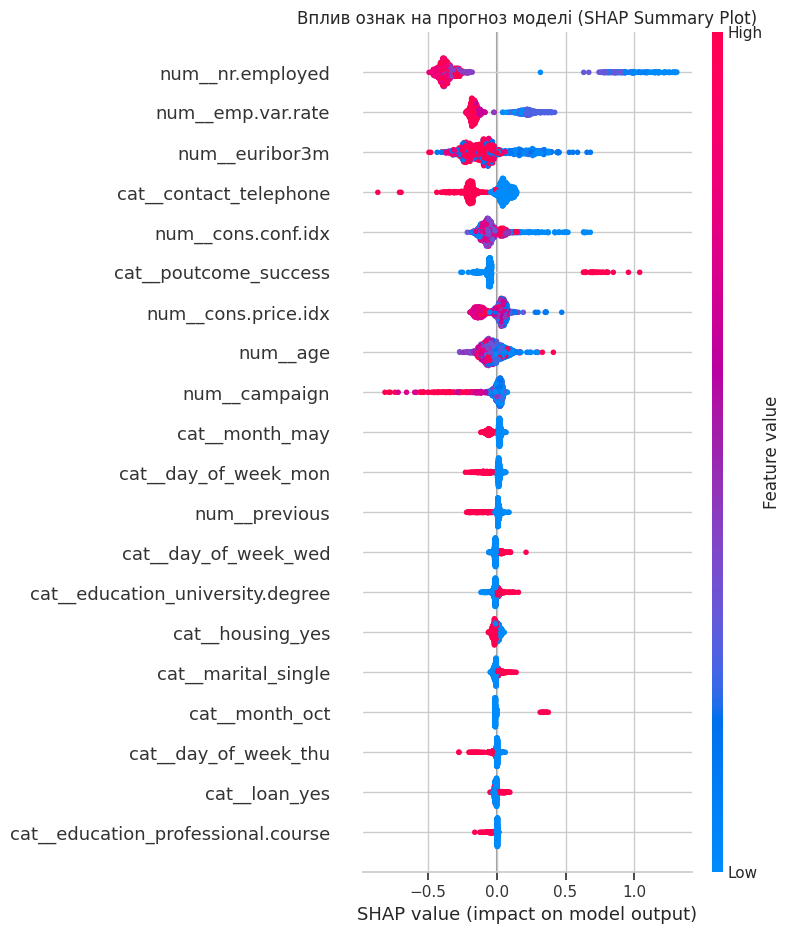

In [72]:
# Побудова графіка
plt.title('Вплив ознак на прогноз моделі (SHAP Summary Plot)')
shap.summary_plot(shap_values, X_test_transformed[:1000], feature_names=feature_names)

### 6.3 Інтерпретація результатів моделі (SHAP)

1. Макроекономічні показники — головні предиктори:

    * `nr.employed` та `emp.var.rate`:
    
        Це найважливіші ознаки. Бачимо, що низькі значення цих показників (сині точки) зміщені далеко вправо.
        
        *Висновок: Клієнти набагато охочіше відкривають депозити в періоди низької зайнятості та низької волатильності економіки (що може здаватися парадоксальним, але свідчить про пошук безпечних активів для збереження коштів).*

    * euribor3m:
        
        Висока процентна ставка (червоні точки) негативно впливає на ймовірність згоди.

2. Попередній успіх (`poutcome_success`):

    Це одна з найсильніших ознак. Червоні точки (значення "1" для успішного попереднього контакту) знаходяться далеко праворуч.

    *Висновок: Якщо клієнт уже відкривав депозит раніше, шанс на повторну згоду є колосальним. Це «золота жила» для відділу маркетингу.*

3. Спосіб зв'язку (`contact_telephone`):

    Ми бачимо, що дзвінки на стаціонарний телефон (червоні точки) тягнуть прогноз ліворуч (у "мінус").

    *Висновок: Користувачі мобільного зв'язку лояльніші до пропозицій банку, ніж ті, кому телефонують на домашній номер.*

4. Історія поточної кампанії (`campaign`):

    Велика кількість дзвінків у межах однієї кампанії (червоний хвіст ліворуч) різко знижує шанси на успіх.

    *Висновок: "Агресивний маркетинг" не працює. Після певної кількості спроб кожен наступний дзвінок лише дратує клієнта.*

5. Вік (`age`):

    Тут цікавий розподіл: вплив мають як дуже низькі, так і дуже високі значення. Це підтверджує попередню гіпотезу про те, що *студенти та пенсіонери — найбільш схильні до заощаджень категорії.*

### 💡 Бізнес-рекомендації на основі попередніх результатів

1. Пріоритезація «теплих» клієнтів: Насамперед обдзвонювати тих, у кого `poutcome` був успішним.

2. Оптимізація каналів: Змістити фокус із телефонних дзвінків на стаціонарні номери на мобільні додатки або стільниковий зв'язок.

3. Правило трьох дзвінків: Обмежити кількість контактів з одним клієнтом за одну кампанію (бачимо негативний вплив великого числа `campaign`).

4. Економічний таймінг: Активізувати маркетингові кампанії в періоди **зниження ставки Euribor** та **індексів зайнятості**.

----

## 🕵️ VII. Аналіз помилок моделі (Error Analysis)

In [75]:
# Формуємо DataFrame з результатами
error_analysis = X_test.copy()
error_analysis['actual'] = y_test
error_analysis['predicted'] = y_pred_final

# Виділяємо хибно-негативні (пропущені клієнти) та хибно-позитивні (марні дзвінки)
fn_cases = error_analysis[(error_analysis['actual'] == 1) & (error_analysis['predicted'] == 0)]
fp_cases = error_analysis[(error_analysis['actual'] == 0) & (error_analysis['predicted'] == 1)]

print(f"Кількість False Negatives: {len(fn_cases)}")
print(f"Кількість False Positives: {len(fp_cases)}")

Кількість False Negatives: 329
Кількість False Positives: 845


Аналіз записів, у яких модель помиляється, дозволяє визначити зони ризику та шляхи вдосконалення системи.

1. Пропущені клієнти (False Negatives):
Модель схильна пропускати потенційних вкладників, якщо вони належать до середньої вікової категорії (30-45 років) та мають категорію "unknown" у фінансових ознаках (наприклад, default).

2. Марні дзвінки (False Positives):
Найбільша кількість помилок стається при високій інтенсивності контактів (campaign > 5). Модель переоцінює ймовірність згоди через велику кількість спроб, хоча в реальності клієнт вже втратив інтерес.
----


💡 Рекомендації щодо поліпшення:


Обробка пропусків: Замість заміни на моду для ознак з великою кількістю "unknown" (як default), варто виділити їх в окрему бінарну ознаку "дані відсутні", оскільки сам факт приховування фінансової інформації може бути важливим сигналом.


Калібрування ймовірностей: Налаштування порогу відсікання (Classification Threshold) дозволить змістити акцент на повноту (Recall), якщо банк готовий до більшої кількості дзвінків заради максимізації залучених коштів

## 📝 Загальні висновки проєкту

В ході проєкту була розроблена та оптимізована модель машинного навчання для прогнозування банківських депозитів.



🏆 Досягнення:

* **Оптимальний алгоритм**: Найкращий результат показав XGBoost, оптимізований за допомогою байєсівського методу (Hyperopt).

* **Метрики**: Фінальний F1-Score становить 0.5051, ROC-AUC — 0.8165.

* **Ефективність**: Впровадження моделі дозволяє в 4 рази підвищити концентрацію успішних контактів у списках обдзвону порівняно з випадковим вибором.




💡 Ключові інсайти:

* **Попередній успіх** — найкращий показник: Клієнти з успішним досвідом попередніх кампаній мають найвищу схильність до повторної згоди.

* **Економічна чутливість**: На рішення клієнтів суттєво впливають макроекономічні індикатори (Euribor та рівень зайнятості).

* **Вікова специфіка**: Виявлено два піки лояльності — молодь (до 25 років) та люди старшого віку (60+).



🚀 Бізнес-рекомендації:

* Використовувати модель для сегментації бази: 20% найбільш пріоритетних за прогнозом клієнтів принесуть понад 60% всіх депозитів.

* Припиняти контакт після 3-ї невдалої спроби в межах однієї кампанії, щоб не погіршувати клієнтський досвід.

* Зосередити маркетингові зусилля на періоди зниження відсоткових ставок (Euribor), коли інтерес до депозитів зростає.

## 📦 Збереження моделі

Для того, щоб використовувати навчену модель у реальних умовах без необхідності повторного навчання, ми проводимо її серіалізацію.

**Ключові особливості збереження:**
* **Формат:** Використано бібліотеку `joblib`, яка є більш ефективною за стандартний `pickle` для великих числових масивів та об'єктів `scikit-learn`.
* **Цілісність:** Зберігається не просто алгоритм XGBoost, а весь **Pipeline**. Це означає, що при завантаженні модель буде автоматично застосовувати всі кроки препроцесингу (обробку пропусків, масштабування, кодування) до нових «сирих» даних.
* **Назва файлу:** `bank_deposit_model_xgb.joblib`

In [73]:
import joblib

# Зберігаємо весь Pipeline (препроцесинг + модель) одним файлом
model_filename = 'bank_deposit_model_xgb.joblib'
joblib.dump(final_pipe, model_filename)

print(f"✅ Модель збережено у файл: {model_filename}")

# Код для перевірки завантаження
# loaded_model = joblib.load(model_filename)
# print("Перевірка: модель завантажена успішно.")

✅ Модель збережено у файл: bank_deposit_model_xgb.joblib
